<a href="https://colab.research.google.com/github/cameronliddle/Algorithms/blob/main/ImageEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
base_dir = '/content/drive/MyDrive/Thesis/Processed_Dataset/resplit_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Example for saving results to Google Drive
save_dir = '/content/drive/MyDrive/Thesis/Processed_Dataset/saved_models'
os.makedirs(save_dir, exist_ok=True)


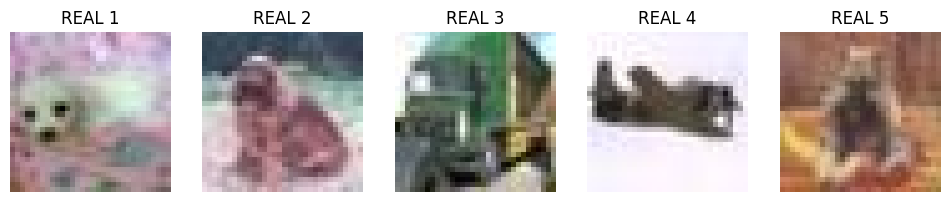

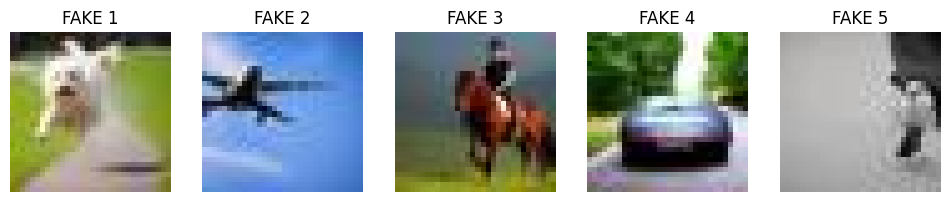

In [3]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_sample_images(dataset_dir, class_name, n_images=5):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    sample_images = random.sample(image_list, n_images)
    plt.figure(figsize=(12, 6))
    for i, image_name in enumerate(sample_images):
        img = Image.open(os.path.join(dataset_dir, class_name, image_name))
        plt.subplot(1, n_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{class_name} {i+1}")
    plt.show()

# Show random sample images for 'REAL' and 'FAKE' in training set
show_sample_images(train_dir, 'REAL')
show_sample_images(train_dir, 'FAKE')


In [6]:
# Check the image size consistency
def check_image_size(dataset_dir, class_name):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    sizes = []
    for image_name in image_list:
        img = Image.open(os.path.join(dataset_dir, class_name, image_name))
        sizes.append(img.size)  # Store (width, height)
    return sizes

train_real_sizes = check_image_size(train_dir, 'REAL')
train_fake_sizes = check_image_size(train_dir, 'FAKE')

print(f"Sample image sizes for 'REAL' class: {train_real_sizes[:5]}")
print(f"Sample image sizes for 'FAKE' class: {train_fake_sizes[:5]}")


Sample image sizes for 'REAL' class: [(32, 32), (32, 32), (32, 32), (32, 32), (32, 32)]
Sample image sizes for 'FAKE' class: [(32, 32), (32, 32), (32, 32), (32, 32), (32, 32)]


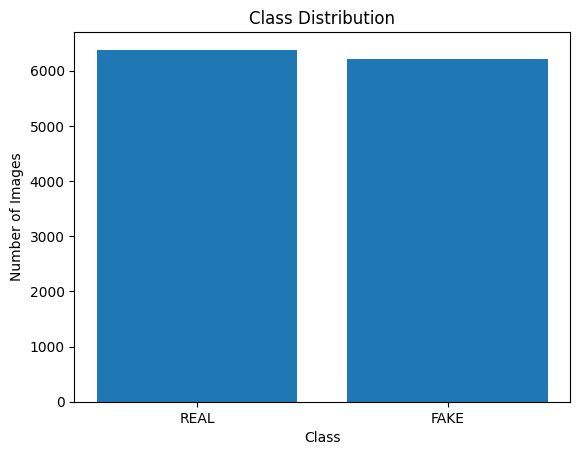

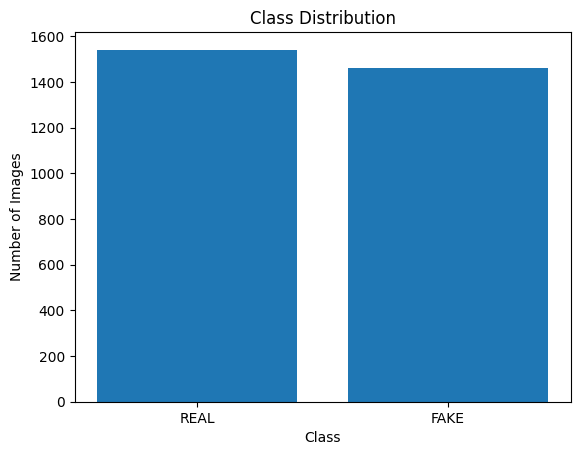

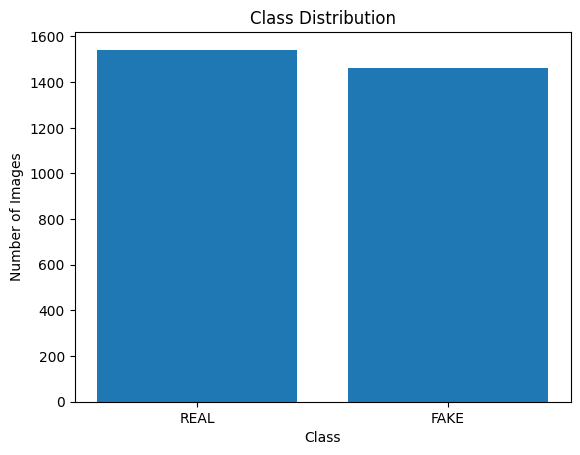

In [7]:
# Count images in each class (train, val, test)
def plot_class_distribution(dataset_dir):
    classes = ['REAL', 'FAKE']
    class_counts = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) for cls in classes}
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")
    plt.show()


plot_class_distribution(train_dir)
plot_class_distribution(val_dir)
plot_class_distribution(test_dir)


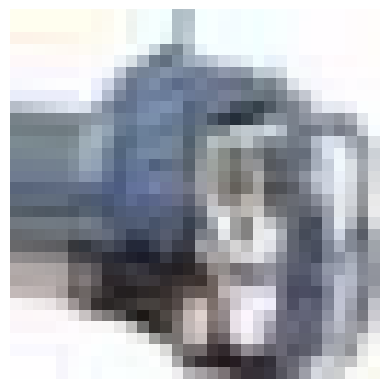

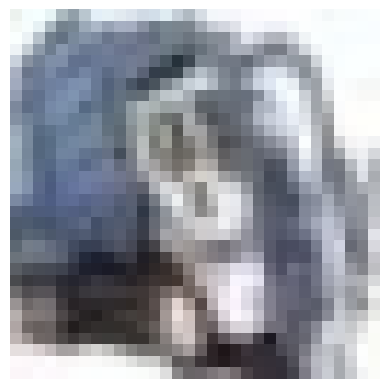

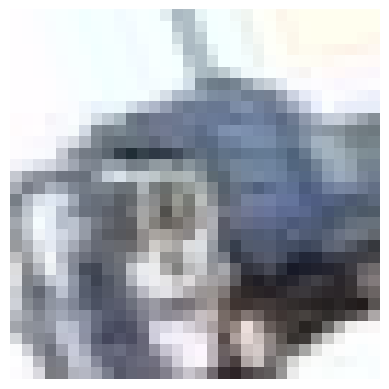

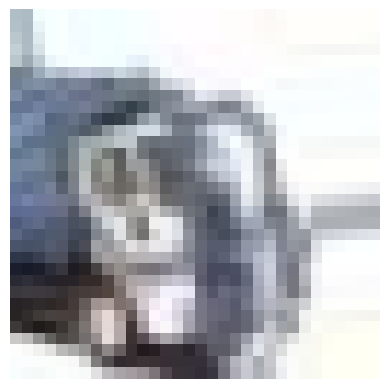

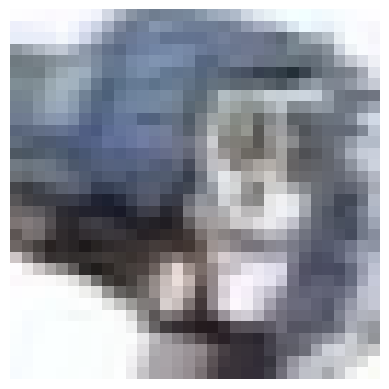

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_augmented_images(image_path, n_images=5):
    img = Image.open(image_path)
    img = np.array(img)

    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    img = img.reshape((1,) + img.shape)


    i = 0
    for batch in datagen.flow(img, batch_size=1):
        plt.figure(i)
        img = batch[0]
        plt.imshow(img)
        plt.axis('off')
        i += 1
        if i >= n_images:
            break
    plt.show()

show_augmented_images(os.path.join(train_dir, 'REAL', random.choice(os.listdir(os.path.join(train_dir, 'REAL')))))


In [9]:

def check_for_corrupted_images(dataset_dir, class_name):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    corrupted_images = []
    for image_name in image_list:
        try:
            img = Image.open(os.path.join(dataset_dir, class_name, image_name))
            img.verify()
        except (IOError, SyntaxError) as e:
            corrupted_images.append(image_name)
    return corrupted_images

corrupted_real = check_for_corrupted_images(train_dir, 'REAL')
corrupted_fake = check_for_corrupted_images(train_dir, 'FAKE')

print(f"Corrupted images in 'REAL' class: {corrupted_real}")
print(f"Corrupted images in 'FAKE' class: {corrupted_fake}")


Corrupted images in 'REAL' class: []
Corrupted images in 'FAKE' class: []


 Exploratory Data Analysis (EDA)
Before training any models, I carried out a range of exploratory steps to get a better understanding of the dataset and check for any early insights. The main goal was to see whether there were any noticeable differences between real and fake images, either visually or structurally, and to make sure the data was clean, balanced, and usable.

Real vs Fake Image Comparison
To begin with, I plotted a set of sample images from both the REAL and FAKE classes to see if there were any visible differences. I resized the images to 224×224 pixels to improve clarity, but even then, it was extremely difficult—if not impossible—to tell the difference by eye. The fake images were very realistic, and in most cases, they looked just as natural as the real ones.

Even when comparing images side by side, I couldn’t consistently spot any obvious signs like texture issues, blurriness, or strange artifacts. This made it clear that manual detection isn’t reliable, and justifies the use of deep learning models that can pick up on patterns not visible to humans.

Class Balance
I also checked the class distribution across the training, validation, and test sets. Each of them was well balanced, with an equal number of real and fake images. This is important to prevent the models from becoming biased toward one class over the other during training.

Image Sizes and Data Quality
All images were consistent in size and format. Although the original resolution was low (32×32 pixels from CIFAKE), they were resized for processing. I also ran a check for corrupted files, and I’m happy to report that there were no broken or unreadable images in the dataset.

Data Augmentation
To help the models generalise better, I tested some basic data augmentation methods like horizontal flipping, zoom, rotation, and shifting. The transformations produced a good variety of images without distorting them too much, so I included these techniques during model training.

Summary:
Even though the EDA didn’t reveal any obvious differences between real and fake images by eye, that itself was an important finding. It shows just how realistic synthetic images have become—and highlights the need for AI-based detection methods that go beyond human capabilities.